## Importar bibliotecas e configurações

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Configurações de visualização
sns.set_style("whitegrid")
nltk.download('stopwords', quiet=True)

True

## Carregar os dados

In [ ]:
df = pd.read_csv('frases.csv', sep=';')

## Entendendo a estrutura do dataset

In [ ]:
df.shape

(100, 2)

O dataframe possui 100 linhas e 2 colunas (Frase e situacao)

## Pré processamento com TF- IDF

In [ ]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['frase'])
y = df['situacao']

## Mapeamento da váriavel target (0= 'baixo risco' 1= 'alto risco')

In [ ]:
mapeamento = {'baixo risco': 0, 'alto risco': 1}
y = df['situacao'].map(mapeamento)


## Remover stop words

In [ ]:
stop_words_pt = stopwords.words('portuguese')

# Removendo e ignorando palavras que possivelmente estão viciando o modelo
stop_words_pt.extend(['sinto', 'tive', 'estou', 'meu', 'uma', 'um'])

# Vetorização TF-IDF com Normalização
tfidf = TfidfVectorizer(stop_words=stop_words_pt, strip_accents='unicode', lowercase=True) # strip_accents remove acentos
X = tfidf.fit_transform(df['frase'])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ate', 'eramos', 'estao', 'estavamos', 'estiveramos', 'estivessemos', 'foramos', 'fossemos', 'ha', 'hao', 'houveramos', 'houverao', 'houveriamos', 'houvessemos', 'ja', 'nao', 'sao', 'sera', 'serao', 'seriamos', 'so', 'tambem', 'tera', 'terao', 'teriamos', 'tinhamos', 'tiveramos', 'tivessemos', 'voce', 'voces'] not in stop_words.
  warnings.warn(


## Divisão dos dados em treino e teste

In [ ]:
# (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=62, shuffle=True)

## Comparação de modelos diferentes

In [ ]:
# Definir os modelos que vamos comparar
modelos = {
    "Regressão Logística": LogisticRegression(),
    "Árvore de Decisão": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # Calculamos métricas focadas em alto risco
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    resultados.append({
        "Modelo": nome,
        "Acurácia": acc,
        "Recall (Alto Risco)": rec,
        "F1-Score": f1
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

                Modelo  Acurácia  Recall (Alto Risco)  F1-Score
0  Regressão Logística      0.80             1.000000  0.777778
1    Árvore de Decisão      0.75             0.714286  0.666667
2        Random Forest      0.80             0.857143  0.750000


## Gerar gráfico comparativo


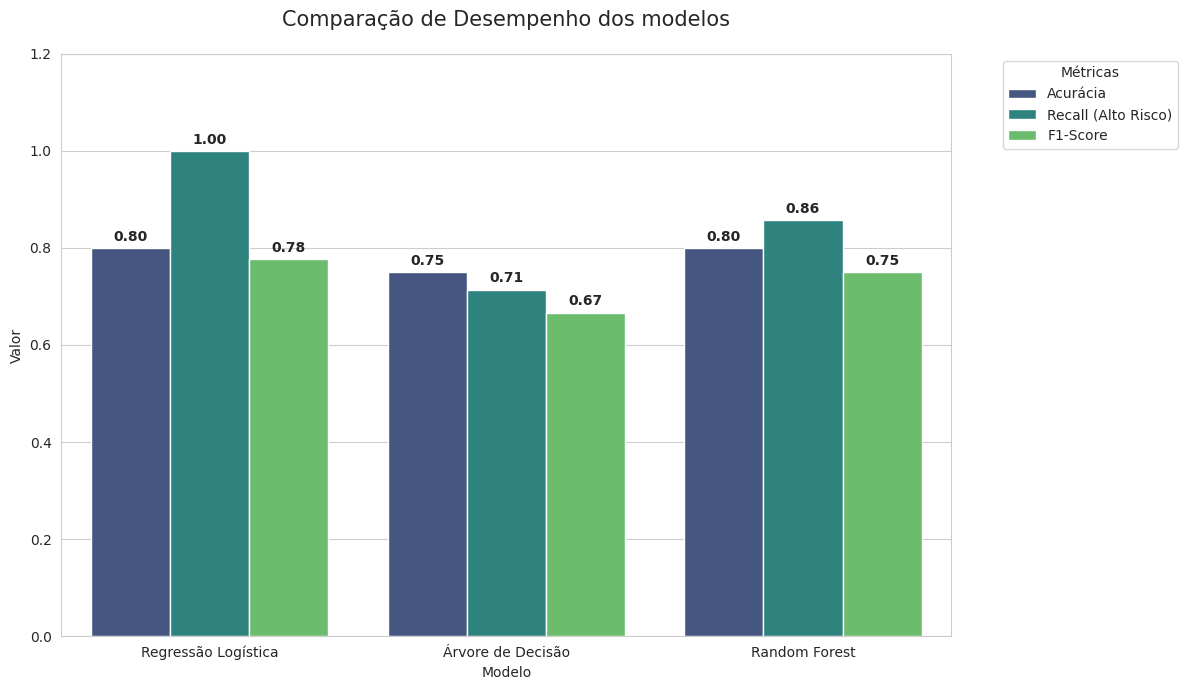

In [ ]:
df_plot = df_resultados.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
grafico = sns.barplot(data=df_plot, x="Modelo", y="Valor", hue="Métrica", palette="viridis")
for container in grafico.containers:
    grafico.bar_label(container, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')
plt.title("Comparação de Desempenho dos modelos", fontsize=15, pad=20)
plt.ylim(0, 1.2)
plt.legend(title="Métricas", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Nesse caso o melhor modelo foi a regressão logística, como o datset tem apenas 100 linhas, os outros modelos são complexos e acabam não sendo tão eficazes

## Testes de generalização

In [ ]:
melhor_modelo = modelos["Regressão Logística"]

def prever_risco(texto):
    vetor = tfidf.transform([texto])
    predicao = melhor_modelo.predict(vetor)
    probabilidade = melhor_modelo.predict_proba(vetor)
    return predicao[0], probabilidade.max()

testes = [
    "Sinto um aperto terrível no coração e meu braço está dormente",
    "Tive uma pequena fisgada no peito após tossir",
    "Meu peito dói mas acho que é apenas gases"
]

print("--- TESTE DE GENERALIZAÇÃO ---")
for frase in testes:
    resultado_num, confianca = prever_risco(frase)
    # Traduzindo o número para o texto amigável
    classe_texto = "ALTO RISCO" if resultado_num == 1 else "BAIXO RISCO"
    print(f"Frase: {frase}")
    print(f"Resultado: {classe_texto} ({confianca*100:.2f}% de confiança)\n")

--- TESTE DE GENERALIZAÇÃO ---
Frase: Sinto um aperto terrível no coração e meu braço está dormente
Resultado: ALTO RISCO (61.22% de confiança)

Frase: Tive uma pequena fisgada no peito após tossir
Resultado: BAIXO RISCO (53.50% de confiança)

Frase: Meu peito dói mas acho que é apenas gases
Resultado: BAIXO RISCO (51.89% de confiança)



## Matriz de confusão

<Figure size 600x400 with 0 Axes>

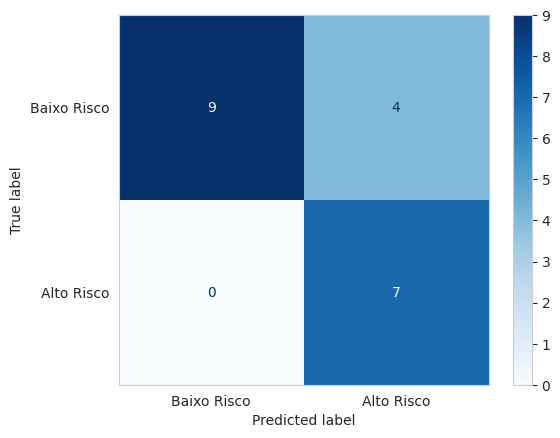

In [ ]:
y_pred_final = melhor_modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1])

plt.figure(figsize=(6,4))
plt.title("Matriz de Confusão - Regressão Logística")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baixo Risco', 'Alto Risco'])
disp.plot(cmap='Blues')
disp.ax_.grid(False)
plt.show()

## Importância das palavras para a classificação do modelo

In [ ]:
modelo_lr = modelos["Regressão Logística"]
pesos = pd.Series(modelo_lr.coef_[0], index=tfidf.get_feature_names_out())
print("Palavras que mais indicam 'alto risco'")
print(pesos.sort_values(ascending=False).head(10))

print("\nPalavras que mais indicam 'baixo risco'")
print(pesos.sort_values(ascending=True).head(10))

Palavras que mais indicam 'alto risco'
dor         0.702529
subita      0.606552
sensacao    0.589261
irradia     0.556779
aguda       0.437204
respirar    0.418969
intensa     0.415985
forte       0.405014
aperto      0.401948
toracica    0.399796
dtype: float64

Palavras que mais indicam 'baixo risco'
leve       -1.186782
pouco      -0.871700
rapida     -0.525368
pontada    -0.476085
muscular   -0.461764
apos       -0.421138
comer      -0.351735
final      -0.342320
tempo      -0.335143
tomo       -0.333062
dtype: float64
